In [15]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import xgboost as xgb

import lightgbm as lgb

import joblib
import matplotlib.pyplot as plt

import seaborn as sns
import os

In [2]:
os.makedirs("../models", exist_ok=True)

os.makedirs("../outputs", exist_ok=True)

In [6]:
df = pd.read_csv(
    "../processed/features_dataset.csv"
)

In [7]:
print(df.head())

print(df.shape)

   max_similarity  mean_similarity  max_entailment  max_contradiction  \
0        0.493778         0.490406             0.0           0.000000   
1        0.542135         0.510072             0.0           0.000000   
2        0.416591         0.401467             0.0           0.000000   
3        0.386189         0.385280             0.0           0.502376   
4        0.400931         0.397153             0.0           0.000000   

   max_neutral  claim_length  entity_count  number_count  negation_present  \
0     0.999059            13             7             0                 0   
1     0.998905            17             7             0                 0   
2     0.994209            18             3             0                 0   
3     0.928322            26             5             0                 0   
4     0.988057            23            11             0                 0   

   evidence_count  avg_word_length  punctuation_count  unique_word_ratio  \
0               

In [8]:
print(df.isnull().sum())

max_similarity                 0
mean_similarity                0
max_entailment                 0
max_contradiction              0
max_neutral                    0
claim_length                   0
entity_count                   0
number_count                   0
negation_present               0
evidence_count                 0
avg_word_length                0
punctuation_count              0
unique_word_ratio              0
uppercase_ratio                0
temporal_expression_present    0
evidence_conflict_score        0
source_reliability_score       0
claim_specificity              0
label                          0
dtype: int64


In [9]:
df = df.fillna(0)

In [10]:
X = df.drop("label", axis=1)

y = df["label"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (40000, 18)
Testing Shape: (10000, 18)


## XGBoost Model

In [16]:
xgb_model = xgb.XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
xgb_preds = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

In [18]:
print("===== XGBOOST RESULTS =====")

print("Accuracy:",
      accuracy_score(y_test, xgb_preds))

print("Precision:",
      precision_score(y_test, xgb_preds))

print("Recall:",
      recall_score(y_test, xgb_preds))

print("F1 Score:",
      f1_score(y_test, xgb_preds))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_probs))

===== XGBOOST RESULTS =====
Accuracy: 0.8404
Precision: 0.8648705096073517
Recall: 0.8135559921414538
F1 Score: 0.8384288317473173
ROC-AUC: 0.9241981201909418


## LightGBM model

In [19]:
lgb_model = lgb.LGBMClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

lgb_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 20358, number of negative: 19642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2979
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508950 -> initscore=0.035804
[LightGBM] [Info] Start training from score 0.035804
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=300, random_state=42, subsample=0.8)

In [20]:
lgb_preds = lgb_model.predict(X_test)

lgb_probs = lgb_model.predict_proba(X_test)[:,1]

In [21]:
print("===== LIGHTGBM RESULTS =====")

print("Accuracy:",
      accuracy_score(y_test, lgb_preds))

print("Precision:",
      precision_score(y_test, lgb_preds))

print("Recall:",
      recall_score(y_test, lgb_preds))

print("F1 Score:",
      f1_score(y_test, lgb_preds))

print("ROC-AUC:",
      roc_auc_score(y_test, lgb_probs))

===== LIGHTGBM RESULTS =====
Accuracy: 0.8415
Precision: 0.8664018398494668
Recall: 0.8141453831041258
F1 Score: 0.8394611566899626
ROC-AUC: 0.9239809898407083


In [22]:
ensemble_probs = (
    xgb_probs + lgb_probs
) / 2

In [23]:
ensemble_preds = (
    ensemble_probs > 0.5
).astype(int)

In [24]:
print("===== ENSEMBLE RESULTS =====")

print("Accuracy:",
      accuracy_score(y_test, ensemble_preds))

print("Precision:",
      precision_score(y_test, ensemble_preds))

print("Recall:",
      recall_score(y_test, ensemble_preds))

print("F1 Score:",
      f1_score(y_test, ensemble_preds))

print("ROC-AUC:",
      roc_auc_score(y_test, ensemble_probs))

===== ENSEMBLE RESULTS =====
Accuracy: 0.8413
Precision: 0.865428750260797
Recall: 0.8149312377210216
F1 Score: 0.8394212283719519
ROC-AUC: 0.9245046995226454


In [25]:
print(
    classification_report(
        y_test,
        ensemble_preds
    )
)

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      4910
           1       0.87      0.81      0.84      5090

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



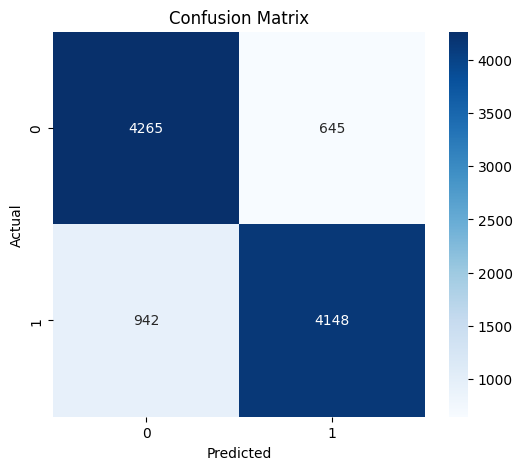

In [26]:
cm = confusion_matrix(
    y_test,
    ensemble_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [27]:
importance_df = pd.DataFrame({

    "feature": X.columns,

    "importance":
        xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

                        feature  importance
3             max_contradiction    0.290825
15      evidence_conflict_score    0.216368
2                max_entailment    0.088659
11            punctuation_count    0.054408
12            unique_word_ratio    0.050185
6                  entity_count    0.048568
17            claim_specificity    0.041751
4                   max_neutral    0.032807
13              uppercase_ratio    0.031345
1               mean_similarity    0.027963
14  temporal_expression_present    0.026493
8              negation_present    0.021366
5                  claim_length    0.018124
7                  number_count    0.014625
16     source_reliability_score    0.012949
0                max_similarity    0.012546
10              avg_word_length    0.011019
9                evidence_count    0.000000


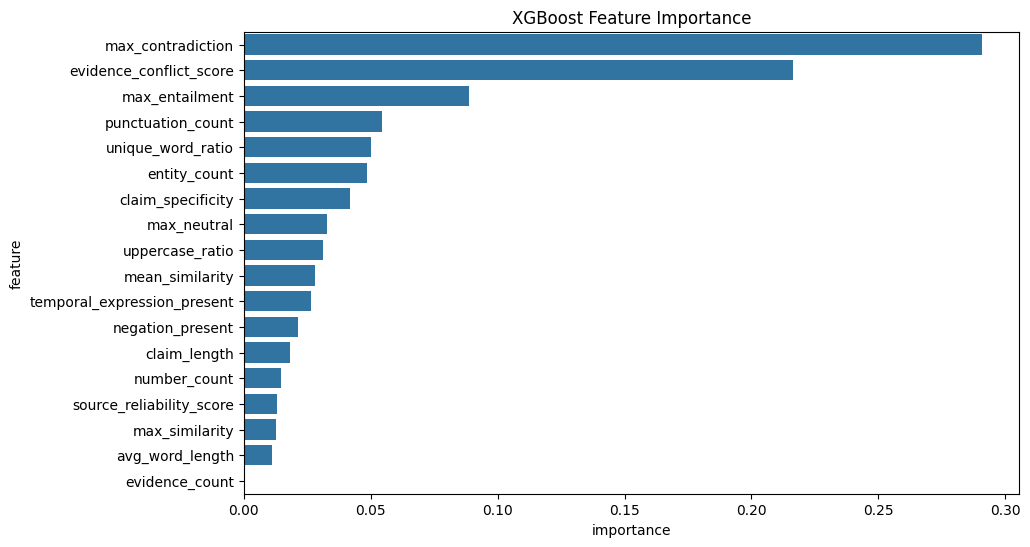

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df
)

plt.title("XGBoost Feature Importance")

plt.show()

In [29]:
xgb_model.save_model(
    "../models/xgboost_model.json"
)

In [30]:
lgb_model.booster_.save_model(
    "../models/lightgbm_model.txt"
)

In [31]:
with open(
    "../outputs/model_metrics.txt",
    "w"
) as f:

    f.write(
        classification_report(
            y_test,
            ensemble_preds
        )
    )

In [32]:
print("XGBoost + LightGBM training completed successfully!")

XGBoost + LightGBM training completed successfully!
